# GloGEM regional NetCDF output check

Inspect and plot the **regional** GlacierMIP4 NetCDF files (no `indiv` in the name), and
cross-check them against the `.dat` output (Section 4).

Set the paths in the config cell, then run all cells.

> For runs reaching 2300, install `nc-time-axis` so matplotlib can plot cftime dates.

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Select files

In [2]:
# Data root (relative to this notebook's folder, output_checks/)
BASE = Path('CentralEurope')

# Regional NetCDF files (full projection)  (EDIT if needed)
NETCDF_DIR     = BASE / 'files' / 'files_netcdf' / 'full'
ANNUAL_FILE    = NETCDF_DIR / 'GloGEM_rgi14_Aletsch_Morteratsch_BCC-CSM2-MR_ssp126_annual.nc'
SUBANNUAL_FILE = NETCDF_DIR / 'GloGEM_rgi14_Aletsch_Morteratsch_BCC-CSM2-MR_ssp126_monthly.nc'

print('annual    :', ANNUAL_FILE, '->', ANNUAL_FILE.exists())
print('sub-annual:', SUBANNUAL_FILE, '->', SUBANNUAL_FILE.exists())

annual    : CentralEurope\files\files_netcdf\full\GloGEM_rgi14_Aletsch_Morteratsch_BCC-CSM2-MR_ssp126_annual.nc -> True
sub-annual: CentralEurope\files\files_netcdf\full\GloGEM_rgi14_Aletsch_Morteratsch_BCC-CSM2-MR_ssp126_monthly.nc -> True


## 2. Inspect dimensions and variables

In [3]:
ds_ann = xr.open_dataset(ANNUAL_FILE)
ds_sub = xr.open_dataset(SUBANNUAL_FILE)

def describe(ds, name):
    print('=' * 70)
    print(name)
    print('=' * 70)
    print('Global attributes:')
    for k, v in ds.attrs.items():
        print('   {}: {}'.format(k, v))
    print('Dimensions:')
    for d, n in ds.sizes.items():
        print('   {}: {}'.format(d, n))
    print('Variables:')
    for vname in ds.variables:
        var = ds[vname]
        units = str(var.attrs.get('units', '-'))
        longn = var.attrs.get('long_name', '')
        cm = var.attrs.get('cell_methods', '')
        cm = '[' + cm + ']' if cm else ''
        print('   {:14s} dims={!s:24} units={:6} {} {}'.format(vname, tuple(var.dims), units, longn, cm))
    print()

describe(ds_ann, 'ANNUAL FILE')
describe(ds_sub, 'SUB-ANNUAL FILE')

ANNUAL FILE
Global attributes:
   Conventions: CF-1.8
   model: GloGEM
   institution: ETH, VAW
   rgi_region: 14
   catchment: Aletsch_Morteratsch
   forcing: BCC-CSM2-MR_ssp126
   gcm: BCC-CSM2-MR
   scenario: ssp126
   gcm_data: cmip6
   period: 1940-2100
   creation_date: Tue Jun 16 16:01:52 2026
Dimensions:
   time: 161
Variables:
   area           dims=('time',)                units=m2     Glacier area [time: point]
   mass           dims=('time',)                units=kg     Glacier mass [time: point]
   mass_bsl       dims=('time',)                units=kg     Glacier mass below sea level [time: point]
   frontal_abl    dims=('time',)                units=kg     Total annual frontal ablation [time: sum]
   time           dims=('time',)                units=-      time [time: point]

SUB-ANNUAL FILE
Global attributes:
   Conventions: CF-1.8
   model: GloGEM
   institution: ETH, VAW
   rgi_region: 14
   catchment: Aletsch_Morteratsch
   forcing: BCC-CSM2-MR_ssp126
   gcm: BCC-CSM

## 3. Plot selected variables

Edit the `panels` list to add/remove variables. Missing variables are skipped automatically.

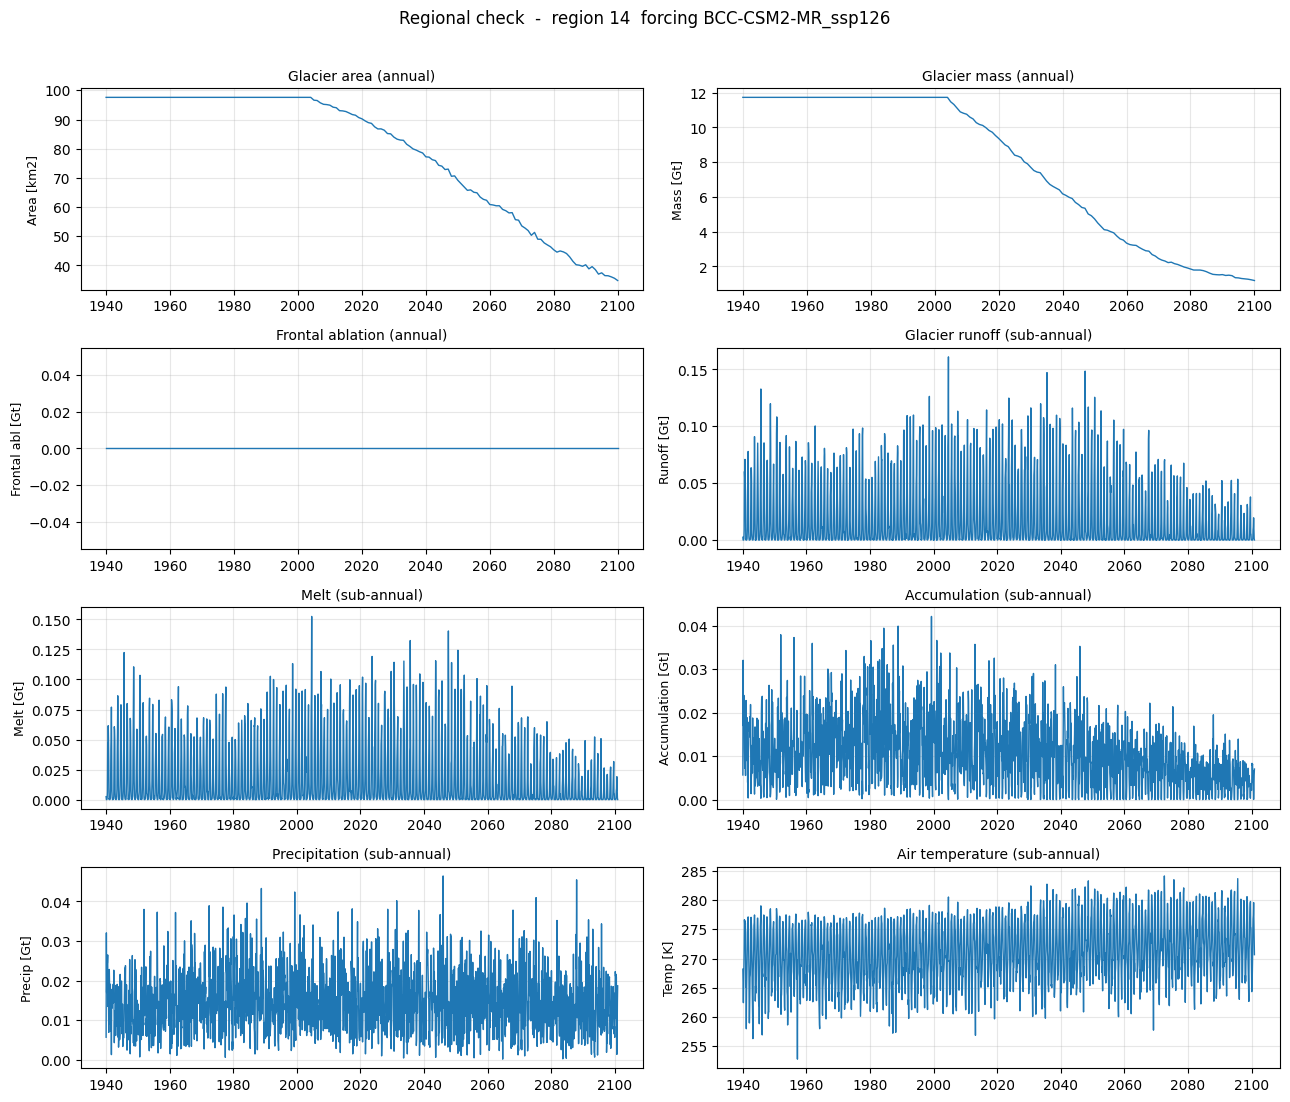

In [4]:
GT  = 1e-12   # kg  -> Gt
KM2 = 1e-6    # m2  -> km2

# (dataset, variable, scale, ylabel, title)
panels = [
    (ds_ann, 'area',        KM2, 'Area [km2]',        'Glacier area (annual)'),
    (ds_ann, 'mass',        GT,  'Mass [Gt]',         'Glacier mass (annual)'),
    (ds_ann, 'frontal_abl', GT,  'Frontal abl [Gt]',  'Frontal ablation (annual)'),
    (ds_sub, 'runoff_glac', GT,  'Runoff [Gt]',       'Glacier runoff (sub-annual)'),
    (ds_sub, 'melt',        GT,  'Melt [Gt]',         'Melt (sub-annual)'),
    (ds_sub, 'acc',         GT,  'Accumulation [Gt]', 'Accumulation (sub-annual)'),
    (ds_sub, 'precip',      GT,  'Precip [Gt]',       'Precipitation (sub-annual)'),
    (ds_sub, 'temp',        1.0, 'Temp [K]',          'Air temperature (sub-annual)'),
]
panels = [p for p in panels if p[1] in p[0].variables]

ncol = 2
nrow = int(np.ceil(len(panels) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.8 * nrow), squeeze=False)
axes = axes.ravel()

for ax, (ds, var, scale, ylabel, title) in zip(axes, panels):
    data = ds[var] * scale
    ax.plot(ds['time'].values, data.values, lw=1.0)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(alpha=0.3)

for ax in axes[len(panels):]:
    ax.set_visible(False)

region  = ds_ann.attrs.get('rgi_region', '?')
forcing = ds_ann.attrs.get('forcing', '?')
fig.suptitle('Regional check  -  region {}  forcing {}'.format(region, forcing), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 4. Compare NetCDF vs .dat (regional sum)

The `.dat` files hold the raw specific values. We convert each glacier row to SI units,
sum across glaciers (keeping only positive contributions, mirroring the NetCDF writer),
and overlay on the regional NetCDF series. They should coincide (`max rel.diff` near 0).

`precip` (different area basis) and `temp` (no `.dat` equivalent) are omitted.

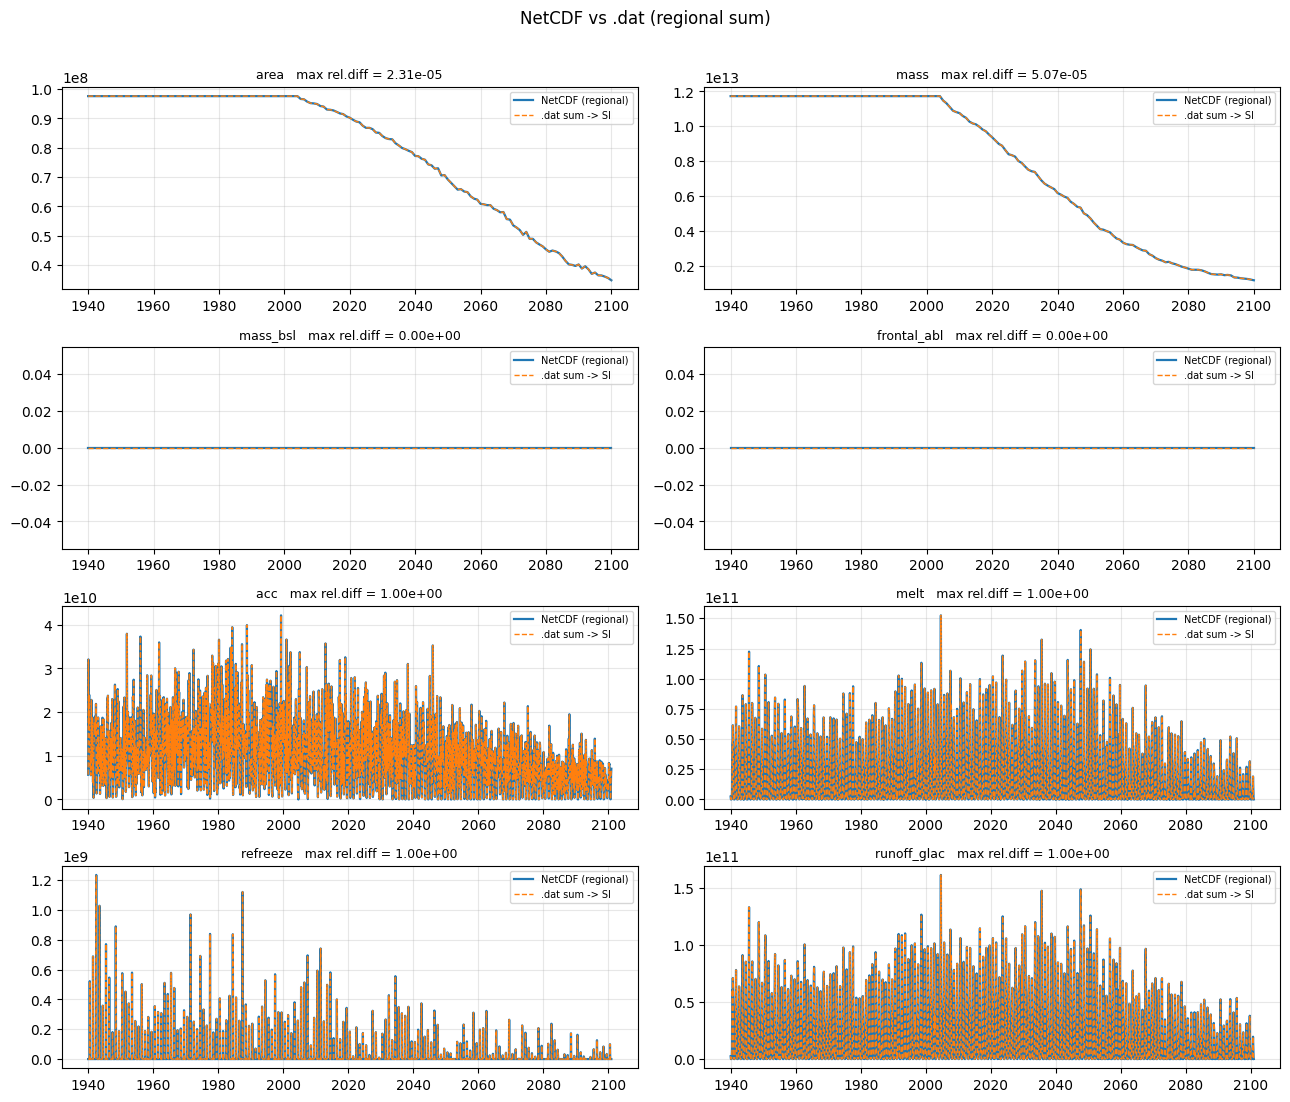

In [5]:
# ---- .dat location (EDIT if needed) ----
DAT_DIR    = BASE / 'files' / 'files_original' / 'BCC-CSM2-MR' / 'ssp126'
DAT_PREFIX = 'centraleurope_'
DAT_SUFFIX = '_r1_Aletsch_Morteratsch.dat'
SLE_FILE   = DAT_DIR / 'centraleurope_Aletsch_Morteratsch_SLE_volbz.dat'

def dat_file(var):
    return DAT_DIR / (DAT_PREFIX + var + DAT_SUFFIX)

def read_dat_rows(path):
    # {glacier_id: values}; first line skipped (monthly files carry a mislabeled header)
    rows = {}
    with open(path) as f:
        f.readline()
        for line in f:
            p = line.split()
            if p:
                rows[p[0]] = np.array(p[1:], dtype=float)
    return rows

def reldiff(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if not np.any(m):
        return np.nan
    denom = np.maximum(np.abs(a[m]), np.abs(b[m]))
    nz = denom > 0
    if not np.any(nz):
        return 0.0
    return np.max(np.abs(a[m][nz] - b[m][nz]) / denom[nz])

# per-glacier annual area [km2] (the area multiplier used by the writer)
area_rows = read_dat_rows(dat_file('Area'))

def regional_sum(datvar, kind, per_area):
    rows = read_dat_rows(dat_file(datvar))
    mats = []
    for k, vals in rows.items():
        if k not in area_rows:
            continue
        a = area_rows[k]
        if kind == 'annual':
            si = {'m2': vals * 1e6, 'vol': vals * 900e9, 'area': vals * a * 1e9}[per_area]
        else:
            si = {'area': vals * np.repeat(a, 12) * 1e9, 'area0': vals * a[0] * 1e9}[per_area]
        mats.append(np.where(si > 0, si, 0.0))   # only positive contributions, like the writer
    return np.sum(np.vstack(mats), axis=0)

def regional_mass_bsl():
    arr = np.atleast_2d(np.loadtxt(SLE_FILE, skiprows=1))
    return arr[:, 1] * 900e9   # km3 -> kg

# (netcdf_var, dataset, builder -> SI array)
comparisons = [
    ('area',         ds_ann, lambda: regional_sum('Area',             'annual',  'm2')),
    ('mass',         ds_ann, lambda: regional_sum('Volume',           'annual',  'vol')),
    ('frontal_abl',  ds_ann, lambda: regional_sum('Frontal_ablation', 'annual',  'area')),
    ('acc',          ds_sub, lambda: regional_sum('Accumulation_mon', 'monthly', 'area')),
    ('melt',         ds_sub, lambda: regional_sum('Melt_mon',         'monthly', 'area')),
    ('refreeze',     ds_sub, lambda: regional_sum('Refreezing_mon',   'monthly', 'area')),
    ('runoff_glac',  ds_sub, lambda: regional_sum('Discharge_gl',     'monthly', 'area')),
    ('runoff_basin', ds_sub, lambda: regional_sum('Discharge',        'monthly', 'area0')),
]
if SLE_FILE.exists():
    comparisons.insert(2, ('mass_bsl', ds_ann, regional_mass_bsl))
comparisons = [c for c in comparisons if c[0] in c[1].variables]

ncol = 2
nrow = int(np.ceil(len(comparisons) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.8 * nrow), squeeze=False)
axes = axes.ravel()
for ax, (ncv, ds, builder) in zip(axes, comparisons):
    t  = ds['time'].values
    nc = np.asarray(ds[ncv].values, float)
    si = builder()
    n  = min(len(t), len(nc), len(si))
    ax.plot(t[:n], nc[:n], lw=1.6, label='NetCDF (regional)')
    ax.plot(t[:n], si[:n], lw=1.0, ls='--', label='.dat sum -> SI')
    ax.set_title('{}   max rel.diff = {:.2e}'.format(ncv, reldiff(nc[:n], si[:n])), fontsize=9)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
for ax in axes[len(comparisons):]:
    ax.set_visible(False)
fig.suptitle('NetCDF vs .dat (regional sum)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### How to read this figure

Each panel overlays the **regional NetCDF** value (solid) against the **sum of the `.dat` rows converted to SI** (dashed) — i.e. every glacier's `.dat` row is converted to SI units and summed across the region (keeping only positive contributions, mirroring the NetCDF writer). They should lie on top of each other, and here they do. The `max rel.diff` in each title is `max(|a−b| / max(|a|,|b|))` over all time steps.


**Why nothing reaches exactly 0:** the `.dat` files are rounded text (fixed decimals per variable), while the NetCDF keeps full float32. The residual differences therefore sit at the `.dat`'s rounding precision — a property of the text files, not a NetCDF error.

**Bottom line:** the regional NetCDF aggregates are consistent with the summed `.dat` output. The high `max rel.diff` values for the sub-annual mass-balance components are artifacts of the relative metric near zero combined with `.dat` text rounding, confirmed by the overlapping curves — not a problem with the NetCDF.
